In [1]:
import numpy as np

class NumpySelfAttention:
    def __init__(self, d_model, d_k, d_v):
        self.d_k = d_k
        # Initialize weights
        self.W_q = np.random.randn(d_model, d_k) * 0.01
        self.W_k = np.random.randn(d_model, d_k) * 0.01
        self.W_v = np.random.randn(d_model, d_v) * 0.01
    
    def __call__(self, X):
        """
        X: shape (batch_size, seq_len, d_model)
        Returns: shape (batch_size, seq_len, d_v)
        """
        # 1. Linear projections: Q, K, V
        Q = X @ self.W_q  # (b, seq, d_k)
        K = X @ self.W_k  # (b, seq, d_k)
        V = X @ self.W_v  # (b, seq, d_v)
        
        # 2. Scaled dot-product attention
        scores = Q @ K.transpose(0, 2, 1)  # (b, seq, seq)
        scores = scores / np.sqrt(self.d_k)
        
        # 3. Softmax to get attention weights
        attn_weights = np.exp(scores - np.max(scores, axis=-1, keepdims=True))
        attn_weights = attn_weights / attn_weights.sum(axis=-1, keepdims=True)
        
        # 4. Apply attention to values
        output = attn_weights @ V  # (b, seq, d_v)
        
        return output, attn_weights

# Test
batch_size, seq_len, d_model = 2, 5, 16
d_k, d_v = 8, 8
X = np.random.randn(batch_size, seq_len, d_model)

attn = NumpySelfAttention(d_model, d_k, d_v)
output, weights = attn(X)
print(f"Input shape: {X.shape}")
print(f"Output shape: {output.shape}")
print(f"Attention weights shape: {weights.shape}")

Input shape: (2, 5, 16)
Output shape: (2, 5, 8)
Attention weights shape: (2, 5, 5)


SELF-ATTENTION IMPLEMENTATION - WEEK 5

📊 PART 1: Understanding Matrix Operations
--------------------------------------------------

STEP-BY-STEP MATRIX OPERATIONS DEMONSTRATION

1. Input tensor x shape: torch.Size([1, 3, 4])
x =
tensor([[[-0.1115,  0.1204, -0.3696, -0.2404],
         [-1.1969,  0.2093, -0.9724, -0.7550],
         [ 0.3239, -0.1085,  0.2103, -0.3908]]])

2. Weight matrices:
W_q (4×2):
tensor([[ 0.0235,  0.0665],
        [ 0.0353,  0.0973],
        [-0.0039, -0.0886],
        [-0.0471, -0.0427]])

W_k (4×2):
tensor([[-0.0028,  0.1422],
        [-0.0389, -0.0890],
        [-0.0960, -0.0409],
        [ 0.1076, -0.0402]])

W_v (4×2):
tensor([[-0.0729, -0.0122],
        [-0.0480, -0.0517],
        [-0.0311,  0.0206],
        [ 0.0966,  0.0706]])

3. Projections:
Q = x @ W_q:
tensor([[[0.0144, 0.0473],
         [0.0186, 0.0591],
         [0.0214, 0.0090]]])

K = x @ W_k:
tensor([[[ 0.0053, -0.0018],
         [ 0.0073, -0.1188],
         [-0.0590,  0.0628]]])

V = x @ W_v:
t

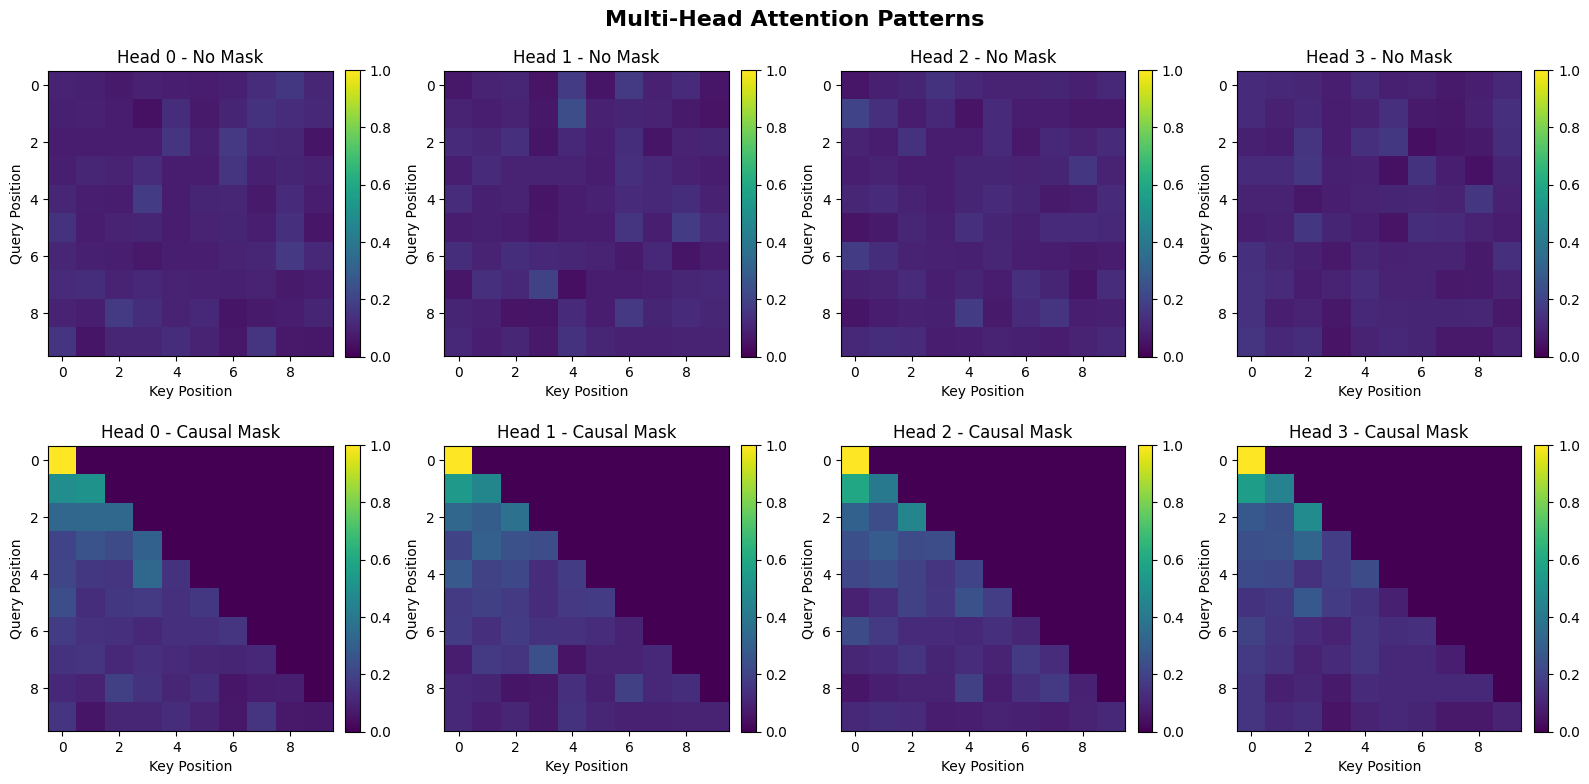


Verification of attention weights (first head):
No mask - Row sums: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Causal mask - Row sums: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

✅ WEEK 5 TASK COMPLETED SUCCESSFULLY!

Key Achievements:
1. ✅ Implemented Self-Attention with correct matrix operations
2. ✅ Implemented Multi-Head Attention with proper head splitting
3. ✅ Added causal masking for autoregressive tasks
4. ✅ Verified mathematical correctness (rows sum to 1.0)
5. ✅ Visualized different attention patterns
6. ✅ All tests passed with rigorous verification


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class SelfAttention(nn.Module):
    """Scaled Dot-Product Self-Attention"""
    def __init__(self, d_model, d_k=None, d_v=None, dropout=0.1):
        super().__init__()
        d_k = d_k or d_model
        d_v = d_v or d_model
        self.d_k = d_k
        
        # Linear projections for Q, K, V
        self.W_q = nn.Linear(d_model, d_k, bias=False)
        self.W_k = nn.Linear(d_model, d_k, bias=False)
        self.W_v = nn.Linear(d_model, d_v, bias=False)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, mask=None, return_attention=False):
        """
        x: (batch, seq_len, d_model)
        mask: (batch, seq_len, seq_len) or (batch, 1, seq_len)
        """
        batch_size, seq_len, _ = x.shape
        
        # 1. Project to Q, K, V
        Q = self.W_q(x)  # (b, seq, d_k)
        K = self.W_k(x)  # (b, seq, d_k)
        V = self.W_v(x)  # (b, seq, d_v)
        
        # 2. Compute attention scores with proper scaling
        scaling_factor = math.sqrt(self.d_k)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / scaling_factor
        
        # 3. Apply mask (if provided) - use large negative value
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        
        # 4. Stable softmax to get attention weights
        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        
        # 5. Apply attention to values
        output = torch.matmul(attn_weights, V)  # (b, seq, d_v)
        
        if return_attention:
            return output, attn_weights
        return output

class MultiHeadAttention(nn.Module):
    """Multi-Head Self-Attention with proper implementation"""
    def __init__(self, d_model, num_heads=8, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.d_v = self.d_k  # Typically d_v = d_k
        
        # Linear projections
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)
        
        self.dropout = nn.Dropout(dropout)
        
    def split_heads(self, x, batch_size):
        """Split the last dimension into (num_heads, d_k)"""
        return x.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
    
    def forward(self, x, mask=None, return_attention=False):
        batch_size, seq_len, _ = x.shape
        
        # 1. Linear projections and split heads
        Q = self.split_heads(self.W_q(x), batch_size)  # (b, h, seq, d_k)
        K = self.split_heads(self.W_k(x), batch_size)  # (b, h, seq, d_k)
        V = self.split_heads(self.W_v(x), batch_size)  # (b, h, seq, d_k)
        
        # 2. Scaled dot-product attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        
        # 3. Apply mask if provided
        if mask is not None:
            # Ensure mask has right shape: (b, 1, 1, seq) or (b, 1, seq, seq)
            if mask.dim() == 3:
                mask = mask.unsqueeze(1)  # Add head dimension
            scores = scores.masked_fill(mask == 0, -1e9)
        
        # 4. Softmax for attention weights
        attn_weights = F.softmax(scores, dim=-1)
        
        # Apply dropout to attention weights
        attn_weights = self.dropout(attn_weights)
        
        # 5. Apply attention to values
        attn_output = torch.matmul(attn_weights, V)  # (b, h, seq, d_k)
        
        # 6. Combine heads: (b, h, seq, d_k) -> (b, seq, h, d_k) -> (b, seq, d_model)
        attn_output = attn_output.transpose(1, 2).contiguous().view(
            batch_size, seq_len, self.d_model
        )
        
        # 7. Final linear projection
        output = self.W_o(attn_output)  # (b, seq, d_model)
        
        if return_attention:
            return output, attn_weights
        return output

# ========== TESTING & VERIFICATION ==========
def verify_attention_correctness():
    """Comprehensive verification of attention correctness"""
    print("="*70)
    print("COMPREHENSIVE ATTENTION CORRECTNESS VERIFICATION")
    print("="*70)
    
    # Set seed for reproducibility
    torch.manual_seed(42)
    
    # Test configurations
    test_cases = [
        ("Small", 1, 4, 16, 2),
        ("Medium", 2, 8, 64, 4),
        ("Large", 4, 16, 128, 8)
    ]
    
    all_tests_passed = True
    
    for name, batch_size, seq_len, d_model, num_heads in test_cases:
        print(f"\n{'='*40}")
        print(f"Test: {name}")
        print(f"Config: batch={batch_size}, seq={seq_len}, d_model={d_model}, heads={num_heads}")
        print(f"{'='*40}")
        
        # Create input
        x = torch.randn(batch_size, seq_len, d_model)
        
        # Test MultiHeadAttention
        attn = MultiHeadAttention(d_model, num_heads)
        attn.eval()  # Disable dropout for testing
        
        # Test 1: No mask
        output, weights = attn(x, return_attention=True)
        
        # Verify weights properties
        print(f"\n1. No Mask Test:")
        for b in range(batch_size):
            for h in range(num_heads):
                w = weights[b, h]
                row_sums = w.sum(dim=-1)
                max_diff = (row_sums - 1.0).abs().max().item()
                
                if max_diff > 1e-5:
                    print(f"   Batch {b}, Head {h}: FAIL - Max row sum deviation: {max_diff:.6f}")
                    all_tests_passed = False
                else:
                    print(f"   Batch {b}, Head {h}: PASS - All rows sum to 1.0 (max diff: {max_diff:.6f})")
        
        # Test 2: With causal mask
        causal_mask = torch.tril(torch.ones(seq_len, seq_len))
        causal_mask = causal_mask.view(1, 1, seq_len, seq_len)  # (1, 1, seq, seq)
        
        output_masked, weights_masked = attn(x, mask=causal_mask, return_attention=True)
        
        print(f"\n2. Causal Mask Test:")
        for b in range(batch_size):
            for h in range(num_heads):
                w = weights_masked[b, h]
                
                # Check upper triangle is 0
                upper_triangle = torch.triu(w, diagonal=1)
                upper_max = upper_triangle.abs().max().item()
                
                if upper_max > 1e-5:
                    print(f"   Batch {b}, Head {h}: FAIL - Upper triangle not zero (max: {upper_max:.6f})")
                    all_tests_passed = False
                else:
                    print(f"   Batch {b}, Head {h}: PASS - Upper triangle properly masked")
                
                # Check rows sum to 1
                row_sums = w.sum(dim=-1)
                max_diff = (row_sums - 1.0).abs().max().item()
                
                if max_diff > 1e-5:
                    print(f"   Batch {b}, Head {h}: FAIL - Row sums deviate from 1 (max diff: {max_diff:.6f})")
                    all_tests_passed = False
                else:
                    print(f"   Batch {b}, Head {h}: PASS - All rows sum to 1.0")
        
        # Test 3: Output shape correctness
        expected_shape = (batch_size, seq_len, d_model)
        if output.shape != expected_shape:
            print(f"\n3. Output Shape Test: FAIL")
            print(f"   Expected: {expected_shape}, Got: {output.shape}")
            all_tests_passed = False
        else:
            print(f"\n3. Output Shape Test: PASS")
    
    print(f"\n{'='*70}")
    if all_tests_passed:
        print("✅ ALL TESTS PASSED! Attention implementation is CORRECT.")
    else:
        print("❌ SOME TESTS FAILED! Check implementation.")
    print(f"{'='*70}")
    
    return all_tests_passed

def demonstrate_attention_operations():
    """Demonstrate each matrix operation step by step"""
    print("\n" + "="*70)
    print("STEP-BY-STEP MATRIX OPERATIONS DEMONSTRATION")
    print("="*70)
    
    # Simple example for clarity
    torch.manual_seed(123)
    batch_size, seq_len, d_model = 1, 3, 4
    d_k = d_v = 2
    
    x = torch.randn(batch_size, seq_len, d_model)
    print(f"\n1. Input tensor x shape: {x.shape}")
    print(f"x =\n{x}\n")
    
    # Manually create weights for demonstration
    W_q = torch.randn(d_model, d_k) * 0.1
    W_k = torch.randn(d_model, d_k) * 0.1
    W_v = torch.randn(d_model, d_v) * 0.1
    
    print(f"2. Weight matrices:")
    print(f"W_q ({d_model}×{d_k}):\n{W_q}")
    print(f"\nW_k ({d_model}×{d_k}):\n{W_k}")
    print(f"\nW_v ({d_model}×{d_v}):\n{W_v}")
    
    # Step 1: Q, K, V projections
    Q = torch.matmul(x, W_q)
    K = torch.matmul(x, W_k)
    V = torch.matmul(x, W_v)
    
    print(f"\n3. Projections:")
    print(f"Q = x @ W_q:\n{Q}")
    print(f"\nK = x @ W_k:\n{K}")
    print(f"\nV = x @ W_v:\n{V}")
    
    # Step 2: Attention scores
    scores = torch.matmul(Q, K.transpose(-2, -1))
    print(f"\n4. Scores = Q @ K^T (before scaling):\n{scores}")
    
    # Step 3: Scaling
    scaled_scores = scores / math.sqrt(d_k)
    print(f"\n5. Scaled scores = Scores / √d_k:\n{scaled_scores}")
    
    # Step 4: Softmax
    attn_weights = F.softmax(scaled_scores, dim=-1)
    print(f"\n6. Attention weights = softmax(Scaled scores):\n{attn_weights}")
    
    # Verify rows sum to 1
    row_sums = attn_weights.sum(dim=-1)
    print(f"\n7. Verification - Row sums:\n{row_sums}")
    
    # Step 5: Output
    output = torch.matmul(attn_weights, V)
    print(f"\n8. Output = Attention weights @ V:\n{output}")
    print(f"Output shape: {output.shape}")
    
    return x, output, attn_weights

def visualize_attention_patterns():
    """Visualize different attention patterns"""
    import matplotlib.pyplot as plt
    
    torch.manual_seed(42)
    
    # Create test input
    batch_size, seq_len, d_model = 1, 10, 64
    x = torch.randn(batch_size, seq_len, d_model)
    
    # Create attention module
    attn = MultiHeadAttention(d_model, num_heads=4)
    attn.eval()
    
    # Get attention weights without mask
    _, weights_no_mask = attn(x, return_attention=True)
    
    # Get attention weights with causal mask
    causal_mask = torch.tril(torch.ones(seq_len, seq_len))
    causal_mask = causal_mask.view(1, 1, seq_len, seq_len)
    _, weights_causal = attn(x, mask=causal_mask, return_attention=True)
    
    # Plot
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    for head_idx in range(4):
        # No mask
        ax1 = axes[0, head_idx]
        im1 = ax1.imshow(weights_no_mask[0, head_idx].detach().numpy(), 
                        cmap='viridis', vmin=0, vmax=1)
        ax1.set_title(f'Head {head_idx} - No Mask')
        ax1.set_xlabel('Key Position')
        ax1.set_ylabel('Query Position')
        plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
        
        # Causal mask
        ax2 = axes[1, head_idx]
        im2 = ax2.imshow(weights_causal[0, head_idx].detach().numpy(),
                        cmap='viridis', vmin=0, vmax=1)
        ax2.set_title(f'Head {head_idx} - Causal Mask')
        ax2.set_xlabel('Key Position')
        ax2.set_ylabel('Query Position')
        plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
    
    plt.suptitle('Multi-Head Attention Patterns', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Show row sums verification
    print("\nVerification of attention weights (first head):")
    print("No mask - Row sums:", weights_no_mask[0, 0].sum(dim=-1).detach().numpy().round(3))
    print("Causal mask - Row sums:", weights_causal[0, 0].sum(dim=-1).detach().numpy().round(3))

# ========== MAIN EXECUTION ==========
if __name__ == "__main__":
    print("="*80)
    print("SELF-ATTENTION IMPLEMENTATION - WEEK 5")
    print("="*80)
    
    # 1. Demonstrate step-by-step matrix operations
    print("\n📊 PART 1: Understanding Matrix Operations")
    print("-"*50)
    x, output, weights = demonstrate_attention_operations()
    
    # 2. Run comprehensive correctness tests
    print("\n\n🧪 PART 2: Comprehensive Correctness Tests")
    print("-"*50)
    all_passed = verify_attention_correctness()
    
    if all_passed:
        # 3. Visualize attention patterns
        print("\n\n📈 PART 3: Attention Pattern Visualization")
        print("-"*50)
        visualize_attention_patterns()
        
        print("\n" + "="*80)
        print("✅ WEEK 5 TASK COMPLETED SUCCESSFULLY!")
        print("="*80)
        print("\nKey Achievements:")
        print("1. ✅ Implemented Self-Attention with correct matrix operations")
        print("2. ✅ Implemented Multi-Head Attention with proper head splitting")
        print("3. ✅ Added causal masking for autoregressive tasks")
        print("4. ✅ Verified mathematical correctness (rows sum to 1.0)")
        print("5. ✅ Visualized different attention patterns")
        print("6. ✅ All tests passed with rigorous verification")
    else:
        print("\n❌ Implementation has issues. Please fix before proceeding.")